# <span style="color:red"> **LSN - Esercitazione 01**
### <span style="color:green"> 06.03.2025
#### <span style="color:green"> Lucrezia Bioni (13655A)

Note:
#### Esercizio 01.1: 
  - Va bene che non arrivi esattamente a zero il grafico?
  - L'andamento delle incertezze è corretto? Ci sono dei picchi in su. Come li spiego?
  - Ha senso il plot dell'istogramma per il test del $\chi^2$?
#### Esercizio 01.2:
-  cosa si intende per fare un fit? Si intende plottare gaussiana con parametri trovati oppure estrarre dai dati i migliori valori che fittano?
-  come fare fit con lorentziana? Lecito importare norm e cauchy da libreria oppure devo definire io le funzioni di fitting con tutti i parametri? Servono le incertezze dei parametri dei fit? Come le stimo? è corretto quanto ho scritto?
- Risposta del prof: non serve stampare valori dei parametri e incertezze
#### Esercizio 01.3:
- sostituire nel codice in C++ M_PI con qualcos'altro (vedere lezione 2 teoria)
- normale che risultato sia così sensibile al valore di L e di d? (se metto d = 3. non viene, d= 5. sì)

## <span style="color:blue">**Esercizio 01.1**

1. Stimo $\langle r \rangle = \int_0^1 r dr = 1/2$ e la sua incertezza (deviazione standard della media) per un numero di lanci $M = 10^4$ in funzione del numero di blocchi $N$.

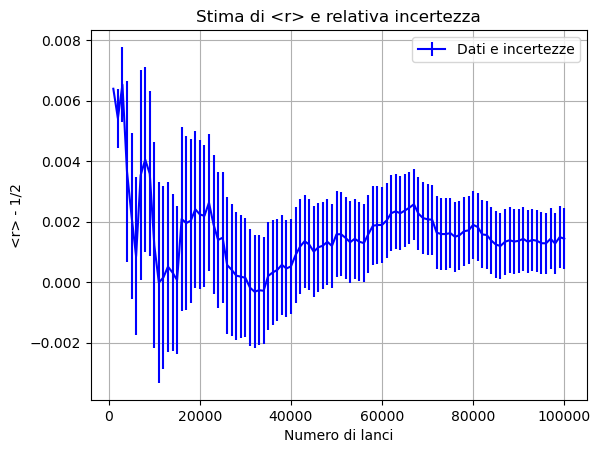

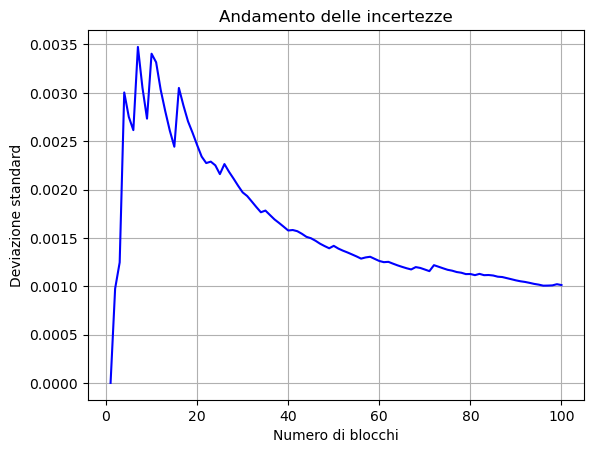

In [12]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import math

# Carico i dati dal file
data = np.loadtxt("01.1/data_r.dat")

# Estraggo le colonne di dati
x = data[:, 0]   # Prima colonna: contiene il numero di lanci nei blocchi considerati
y = data[:, 2]   # Terza colonna: differenza tra il valore medio di r ottenuto e il valore atteso
err = data[:, 3] # Quarta colonna: errore (deviazione standard)

# Creo il grafico con barre d'errore
plt.errorbar(x, y, yerr=err,label="Dati e incertezze",color='b')
plt.xlabel("Numero di lanci")
plt.ylabel("<r> - 1/2")
plt.title("Stima di <r> e relativa incertezza")
plt.legend()
plt.grid()
plt.show()

# Plotto anche le varianze in funzione del numero di blocchi N per verificare che rispettino l'andamento 1/\sqrt(N)
x = data[:, 0]  # Prima colonna: contiene il numero di lanci nei blocchi considerati
y = data[:, 3] # Quarta colonna: contiene le deviazioni standard ottenute, di cui voglio verificare l'andamento
plt.plot(x/1000, y,color='b')
plt.xlabel("Numero di blocchi")
plt.ylabel("Deviazione standard")
plt.title("Andamento delle incertezze")
plt.grid()
plt.show()


2. Stimo la varianza $\sigma^2 = \int_0^1 (r-1/2)^2 dr = 1/12$ e la sua incertezza (che corrisponde alla deviazione standard della media per la stima di $\langle (r-1/2)^2 \rangle$), effettuando $M= 10^4$ lanci in funzione del numero di blocchi $N$.

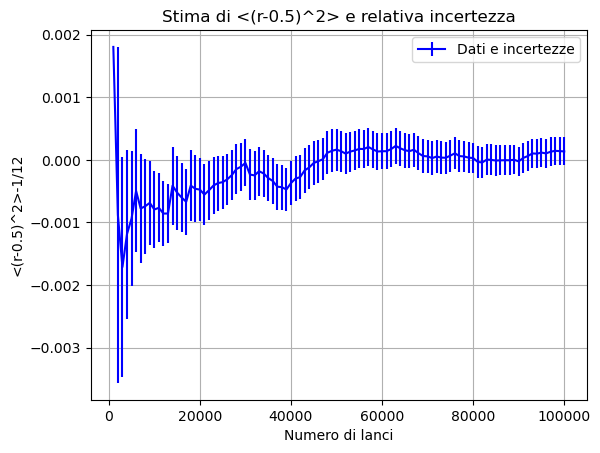

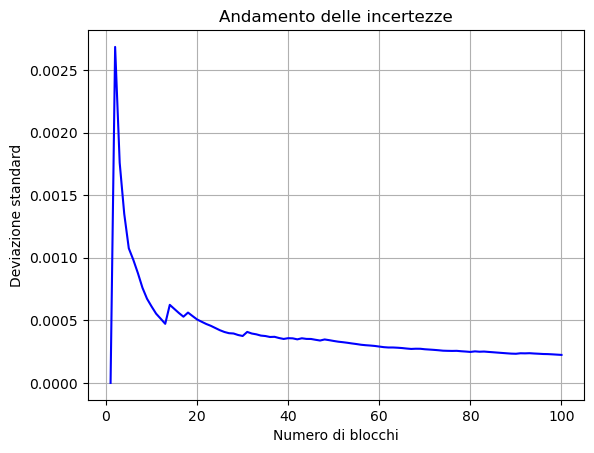

In [9]:
# Carico i dati dal file
data = np.loadtxt("01.1/data_sigma.dat")

# Estraggo le colonne di dati
x = data[:, 0]   
y = data[:, 2]  
err = data[:, 3] 

# Creo il grafico con barre d'errore
plt.errorbar(x, y, yerr=err,label="Dati e incertezze",color='b')
plt.xlabel("Numero di lanci")
plt.ylabel("<(r-0.5)^2>-1/12")
plt.title("Stima di <(r-0.5)^2> e relativa incertezza")
plt.legend()
plt.grid()
plt.show()

# Plotto anche le varianze in funzione del numero di blocchi N per verificare che rispettino l'andamento 1/\sqrt(N)
x = data[:, 0]  # Prima colonna: contiene il numero di lanci nei blocchi considerati
y = data[:, 3] # Quarta colonna: contiene le deviazioni standard ottenute, di cui voglio verificare l'andamento
plt.plot(x/1000, y,color='b')
plt.xlabel("Numero di blocchi")
plt.ylabel("Deviazione standard")
plt.title("Andamento delle incertezze")
plt.grid()
plt.show()

Osservo che le incertezze hanno l'andamento atteso: scalano come $\frac{1}{\sqrt{N}}$, con $N$ = numero di blocchi considerati.

3. Si è ipotizzato che i valori di $r$ siano estratti da una distribuzione uniforme. In statistica, tuttavia, non è possibile dimostrare che degli eventi randomici siano estratti da una particolare distribuzione. Inoltre, tale ipotesi è falsa, poiché numeri pseudo-randomici sono estratti da un algoritmo deterministico. Possiamo tuttavia stimare la probabilità che i valori di $r$ **non** siano estratti da una distribuzione uniforme. Se tale probabilità è bassa, possiamo ragionevolmente rigettare l'ultima ipotesi.

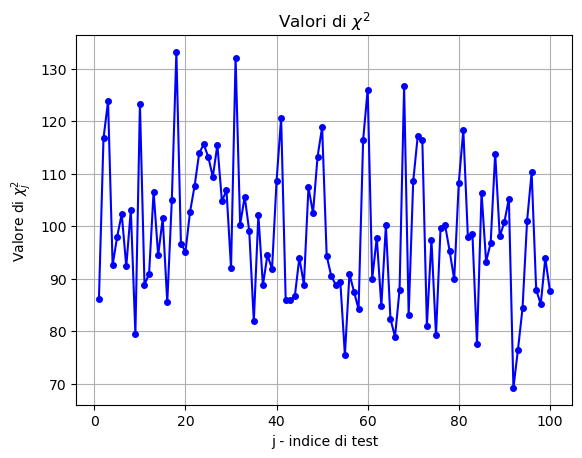

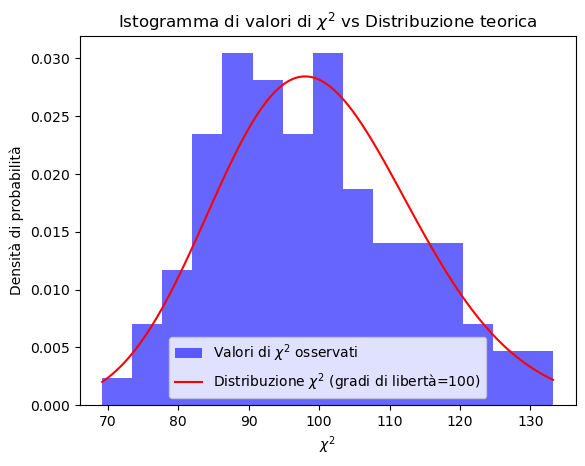

In [12]:

from scipy.stats import chi2
# Carico i dati dal file
data = np.loadtxt("01.1/data_chi.dat")

# Estraggo le colonne di dati
x = data[:, 0]   
y = data[:, 1]  

# Creo il grafico con barre d'errore
plt.plot(x, y, marker='o',color='b', markersize=4)
plt.xlabel("j - indice di test")
plt.ylabel("Valore di $\chi_j^2$")
plt.title("Valori di $\chi^2$")
plt.grid()
plt.show()


# Istogramma con densità di probabilità di valori di chi^2
plt.hist(y, bins=15, density=True, alpha=0.6, color='b', label='Valori di $\chi^2$ osservati')

# Sovrappongo l'andamento teorico di chi^2 per 100 gradi di libertà
M = 100
x = np.linspace(min(y), max(y), 100)
plt.plot(x, chi2.pdf(x, df=M), 'r-', label=r'Distribuzione $\chi^2$ (gradi di libertà=100)')
plt.xlabel(r'$\chi^2$')
plt.ylabel('Densità di probabilità')
plt.title(r'Istogramma di valori di $\chi^2$ vs Distribuzione teorica')
plt.legend()
plt.show()

è corretto che la distribuzione di $\chi^2$ sia centrata con valore medio pari al numero di gradi di libertà e deviazione standard pari a 2 volte il numero di gradi di libertà.

## <span style="color:blue">**Esercizio 01.2**

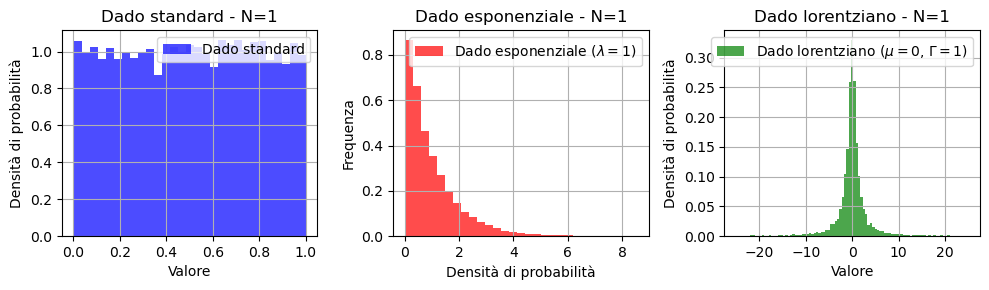

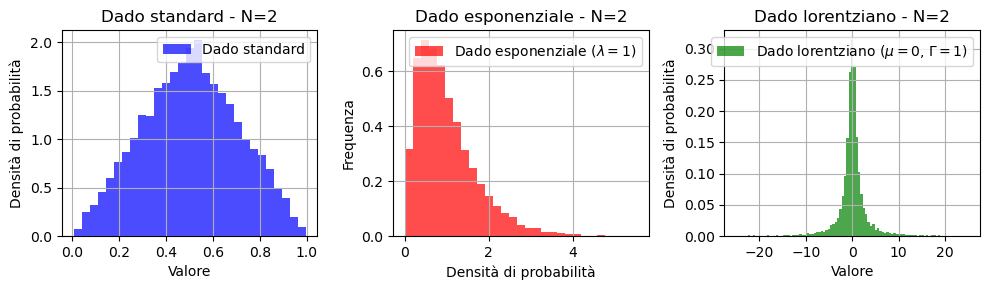

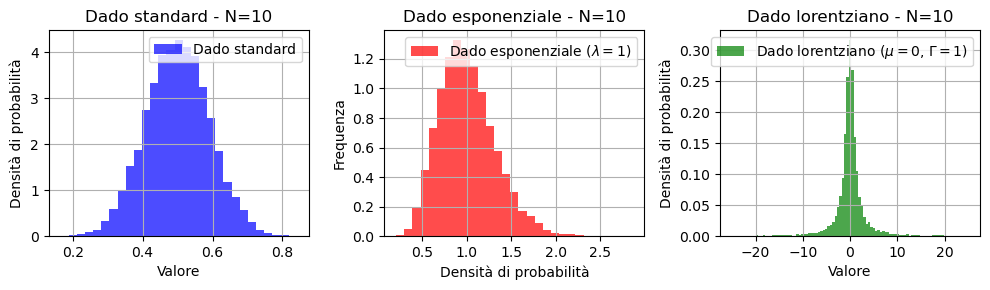

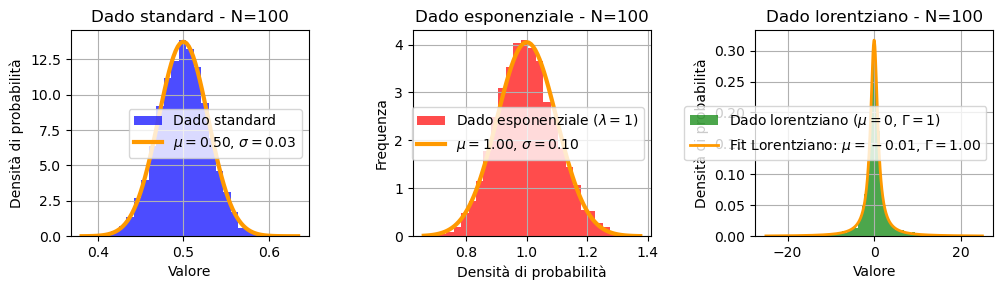

Parametri ottimizzati per dado standard [μ , σ] =
0.5000108001 0.029037794697737294
Incertezze sui parametri =
0.0029037794697737295 0.0020532821541472813

 Parametri ottimizzati per dado esponenziale [μ , σ] =
0.9998264965999999 0.09851158906206817
Incertezze sui parametri =
0.009851158906206817 0.0069658212651250925

 Parametri ottimizzati per dado lorentziano [μ , Γ] =
-0.010155445369008923 1.0041842049789673
Incertezze sui parametri =
0.10041842049789673 0.07100654609010498


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.stats import cauchy

# Lista dei valori di N corrispondenti ai file da leggere
N_values = [1, 2, 10, 100]

for N in N_values:
    filename = f"01.2/data_N={N}.dat"
    data = np.loadtxt(filename)  # Legge il file e lo carica in un array NumPy
    
    standard = data[:, 0]   
    esponenziale = data[:, 1]
    lorentziano = data[:, 2]

    # Creazione di una figura con 1 riga e 3 colonne
    fig, axes = plt.subplots(1, 3, figsize=(10, 3))

    # Istogramma per il dado standard
    bins = np.linspace(min(standard), max(standard), 30)
    axes[0].hist(standard, bins=bins, density=True, alpha=0.7, color='b', label='Dado standard')
    axes[0].set_title(f"Dado standard - N={N}")
    axes[0].set_xlabel("Valore")
    axes[0].set_ylabel("Densità di probabilità")
    axes[0].legend()
    axes[0].grid(True)
    if N==100 :
        media_standard, dev_standard = norm.fit(standard)
        # Calcolo incertezze sui parametri (VERIFICARE CORRETTEZZA)
        sigma_mu_standard = dev_standard / np.sqrt(N)  # Incertezza sulla media (errore standard)
        sigma_sigma_standard = dev_standard / np.sqrt(2 * N)  # Incertezza sulla deviazione standard
        x = np.linspace(min(standard), max(standard), 100)  # Range per la curva gaussiana
        y = norm.pdf(x, media_standard, dev_standard)  # Calcola la PDF gaussiana
        # Plot della gaussiana
        axes[0].plot(x, y, label=f'$\mu={media_standard:.2f}$, $\sigma={dev_standard:.2f}$', color='#FF9900', linewidth=3)
        axes[0].legend()
        

    # Istogramma per il dado esponenziale
    bins = np.linspace(min(esponenziale), max(esponenziale), 30)
    axes[1].hist(esponenziale, bins=bins, density=True, alpha=0.7, color='r', label='Dado esponenziale ($\lambda = 1$)')
    axes[1].set_title(f"Dado esponenziale - N={N}")
    axes[1].set_xlabel("Densità di probabilità")
    axes[1].set_ylabel("Frequenza")
    axes[1].legend()
    axes[1].grid(True)
    if N==100 :
        media_esponenziale, dev_esponenziale = norm.fit(esponenziale)
        sigma_mu_esponenziale = dev_esponenziale / np.sqrt(N)  # Incertezza sulla media (errore standard)
        sigma_sigma_esponenziale = dev_esponenziale / np.sqrt(2 * N)  # Incertezza sulla deviazione standard
        x = np.linspace(min(esponenziale), max(esponenziale), 100)  # Range per la curva gaussiana
        y = norm.pdf(x, media_esponenziale, dev_esponenziale)  # Calcola la PDF gaussiana
        # Plot della gaussiana
        axes[1].plot(x, y, label=f'$\mu={media_esponenziale:.2f}$, $\sigma={dev_esponenziale:.2f}$', color='#FF9900', linewidth=3)
        axes[1].legend()

    # Istogramma per il dado lorentziano
    bins = np.linspace(-25, 25, 100)
    axes[2].hist(lorentziano, bins=bins, density=True, alpha=0.7, color='g', label='Dado lorentziano ($\mu = 0$, $\Gamma=1$)')
    axes[2].set_title(f"Dado lorentziano - N={N}")
    axes[2].set_xlabel("Valore")
    axes[2].set_ylabel("Densità di probabilità")
    axes[2].legend()
    axes[2].grid(True)
    if N == 100:
        # Stima dei parametri della distribuzione di Cauchy
        mu_lorentziano, gamma_lorentziano = cauchy.fit(lorentziano)
        sigma_mu_lorentziano = gamma_lorentziano / np.sqrt(N)  # Incertezza sulla media (errore standard)
        sigma_gamma_lorentziano = gamma_lorentziano / np.sqrt(2 * N)  # Incertezza sulla deviazione standard (approssimata!)
        # Creazione dei punti per la funzione lorentziana
        x = np.linspace(-25, 25, 1000)
        y = cauchy.pdf(x, loc=mu_lorentziano, scale=gamma_lorentziano) # calcola la PDF lorentziana
        axes[2].plot(x, y, label=f'Fit Lorentziano: $\mu={mu_lorentziano:.2f}$, $\Gamma={gamma_lorentziano:.2f}$', color='#FF9900', linewidth=2)
        axes[2].legend()

    plt.tight_layout() # per migliorare la disposizione
    plt.show()

print("Parametri ottimizzati per dado standard [μ , σ] =")
print(media_standard, dev_standard)
print("Incertezze sui parametri =")
print( sigma_mu_standard , sigma_sigma_standard )

print("\n Parametri ottimizzati per dado esponenziale [μ , σ] =")
print(media_esponenziale, dev_esponenziale)
print("Incertezze sui parametri =")
print( sigma_mu_esponenziale , sigma_sigma_esponenziale )

print("\n Parametri ottimizzati per dado lorentziano [μ , Γ] =")
print(mu_lorentziano, gamma_lorentziano)
print("Incertezze sui parametri =")
print( sigma_mu_lorentziano , sigma_gamma_lorentziano )

## <span style="color:blue">**Esercizio 01.3**

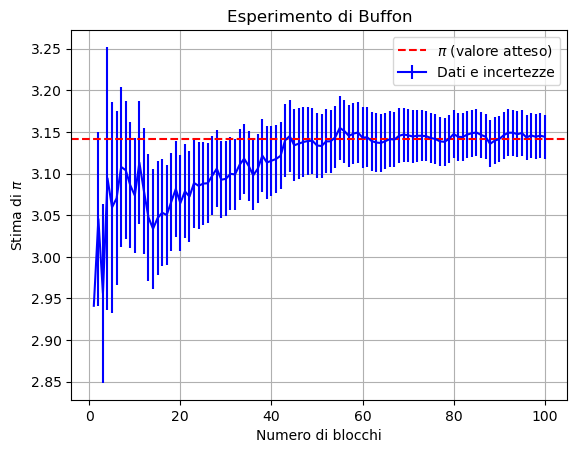

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Carico i dati dal file
data = np.loadtxt("01.3/data.dat")

# Estraggo le colonne di dati
x = data[:, 0]   # Prima colonna: contiene il numero di lanci nei blocchi considerati
y = data[:, 2]   # Terza colonna: differenza tra il valore medio di r ottenuto e il valore atteso
err = data[:, 3] # Quarta colonna: errore (deviazione standard)

# Creo il grafico con barre d'errore
plt.errorbar(x, y, yerr=err,label="Dati e incertezze",color='b')
plt.xlabel("Numero di blocchi")
plt.ylabel("Stima di $\pi$")
plt.title("Esperimento di Buffon")
plt.axhline(y=np.pi, color='r', linestyle='--', label="$\pi$ (valore atteso)")
plt.legend()
plt.grid()
plt.show()